# DQN with CartPole-v1 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `CartPole-v1` using the Gymnassium API for envrionment.

CartPole has a `Box(4,)` **observation space** and a `Discrete(2)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [13]:

import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.tabular_q_matrix import q_matrix_dqn
from analysis.low_rank.rank import plot_matrix_spectra

## Reading the `config` file

In [14]:
# Reading the experiment config file
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = dev if (dev != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_cartpole', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'CartPole-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 100000,
  'batch_size': 64,
  'nn_learning_rate': 0.0005,
  'eps_start': 1.0,
  'eps_min': 0.01,
  'decay_rate': 0.99997,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 1},
 'training': {'no_episodes': 1500, 'target_network_update_steps': 1},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'hankel_rollout', 'kwargs': {'seed': 52}}]}}

## Creating the Envrionment

In [15]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
)
obs_dim = env.observation_space.shape[0]         
n_actions = env.action_space.n                    
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 4 n_actions: 2


## Creating the Agent

In [16]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [17]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
)

## Analysis (Low Rank)

In [18]:
analysis = cfg["analysis"]

# registry mapping config.yaml strings for methods to callable function objects
analysis_methods = {
    "hankel_rollout": hankel_rollout,
    "q_matrix_dqn": q_matrix_dqn,
}

# Each config entry is {name, kwargs}. Resolve `name` to its callable and pre-bind
# the config-supplied `kwargs` with functools.partial, leaving only the runtime
# args (agent, env) for the training loop to inject at call time.
analysis["methods"] = [
    partial(analysis_methods[m["name"]], **m.get("kwargs", {}))
    for m in analysis["methods"]
]
analysis

{'ep_freq': 50,
 'methods': [functools.partial(<function hankel_rollout at 0x138f84860>, seed=52)]}

## Agent Training 

  0%|          | 0/1500 [00:00<?, ?it/s]

episode 0 avg_rewarg: 1.8
Hankel Value Function


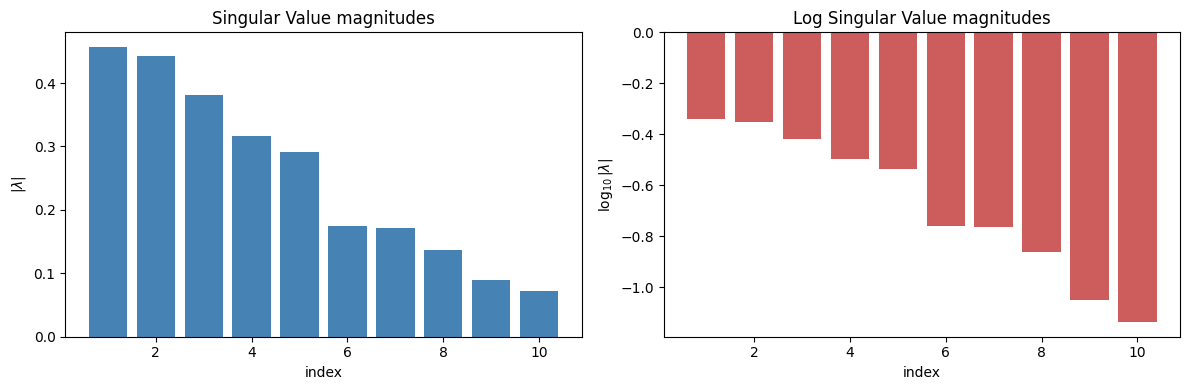

  1%|          | 12/1500 [00:00<01:46, 13.96it/s]

episode 10 avg_rewarg: 27.2


  1%|▏         | 20/1500 [00:01<02:08, 11.52it/s]

episode 20 avg_rewarg: 21.7


  2%|▏         | 33/1500 [00:03<02:32,  9.63it/s]

episode 30 avg_rewarg: 23.1


  3%|▎         | 42/1500 [00:03<02:14, 10.86it/s]

episode 40 avg_rewarg: 20.1


  3%|▎         | 50/1500 [00:04<02:10, 11.14it/s]

episode 50 avg_rewarg: 17.3
Hankel Value Function


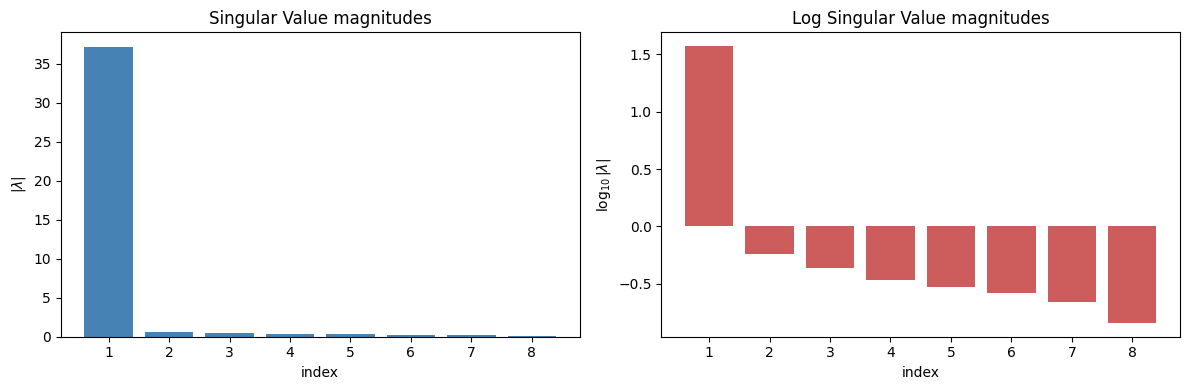

  4%|▍         | 62/1500 [00:06<03:13,  7.43it/s]

episode 60 avg_rewarg: 22.5


  5%|▍         | 71/1500 [00:07<02:55,  8.14it/s]

episode 70 avg_rewarg: 16.5


  5%|▌         | 82/1500 [00:08<03:11,  7.39it/s]

episode 80 avg_rewarg: 20.4


  6%|▌         | 92/1500 [00:10<03:34,  6.58it/s]

episode 90 avg_rewarg: 23.5


  7%|▋         | 100/1500 [00:11<03:52,  6.02it/s]

episode 100 avg_rewarg: 22.4
Hankel Value Function


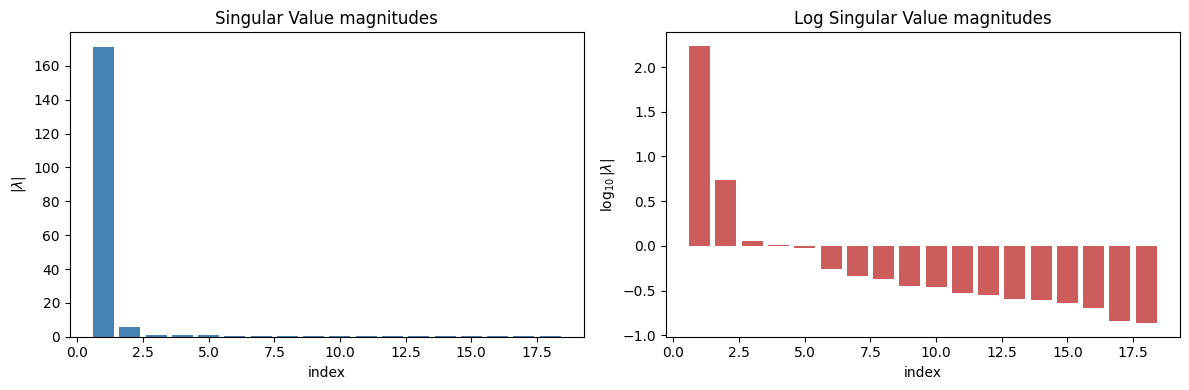

  7%|▋         | 112/1500 [00:14<04:38,  4.99it/s]

episode 110 avg_rewarg: 19.3


  8%|▊         | 122/1500 [00:15<04:25,  5.18it/s]

episode 120 avg_rewarg: 21.4


  9%|▊         | 131/1500 [00:17<04:41,  4.86it/s]

episode 130 avg_rewarg: 25.3


  9%|▉         | 141/1500 [00:20<05:09,  4.39it/s]

episode 140 avg_rewarg: 28.4


 10%|█         | 150/1500 [00:22<05:40,  3.96it/s]

episode 150 avg_rewarg: 23.1
Hankel Value Function


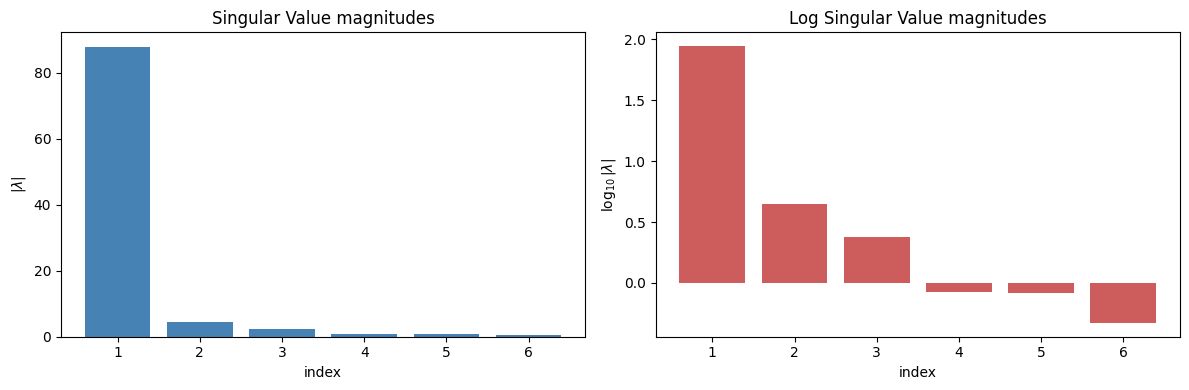

 11%|█         | 161/1500 [00:25<05:42,  3.91it/s]

episode 160 avg_rewarg: 23.5


 11%|█▏        | 171/1500 [00:28<07:29,  2.96it/s]

episode 170 avg_rewarg: 24.7


 12%|█▏        | 181/1500 [00:31<06:33,  3.35it/s]

episode 180 avg_rewarg: 24.8


 13%|█▎        | 191/1500 [00:34<06:57,  3.14it/s]

episode 190 avg_rewarg: 34.9


 13%|█▎        | 200/1500 [00:37<06:59,  3.10it/s]

episode 200 avg_rewarg: 24.4
Hankel Value Function


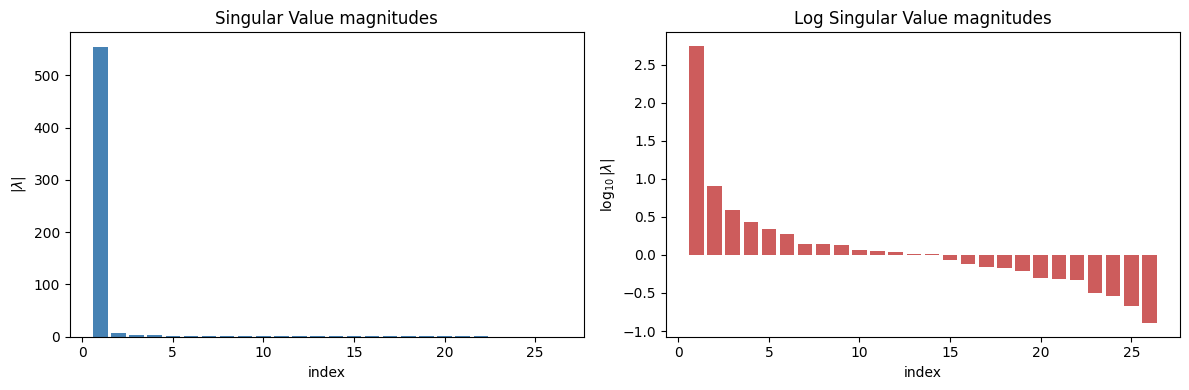

 14%|█▍        | 211/1500 [00:41<08:30,  2.52it/s]

episode 210 avg_rewarg: 23.7


 15%|█▍        | 221/1500 [00:45<08:05,  2.63it/s]

episode 220 avg_rewarg: 18.0


 15%|█▌        | 231/1500 [00:49<07:19,  2.88it/s]

episode 230 avg_rewarg: 18.5


 16%|█▌        | 241/1500 [00:53<07:55,  2.65it/s]

episode 240 avg_rewarg: 17.7


 17%|█▋        | 250/1500 [00:56<07:39,  2.72it/s]

episode 250 avg_rewarg: 16.1
Hankel Value Function


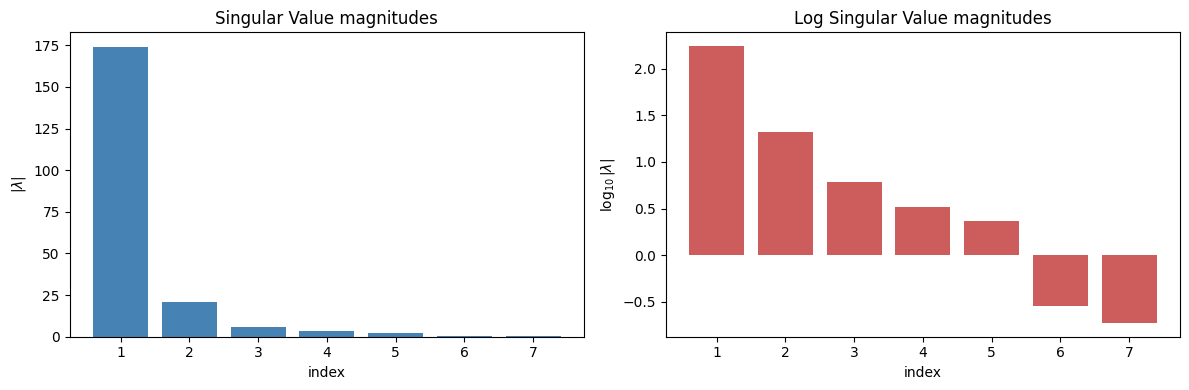

 17%|█▋        | 261/1500 [01:00<08:15,  2.50it/s]

episode 260 avg_rewarg: 25.1


 18%|█▊        | 271/1500 [01:05<08:32,  2.40it/s]

episode 270 avg_rewarg: 29.2


 19%|█▊        | 281/1500 [01:09<08:45,  2.32it/s]

episode 280 avg_rewarg: 20.6


 19%|█▉        | 291/1500 [01:14<09:15,  2.17it/s]

episode 290 avg_rewarg: 28.7


 20%|██        | 300/1500 [01:18<08:49,  2.27it/s]

episode 300 avg_rewarg: 14.2
Hankel Value Function


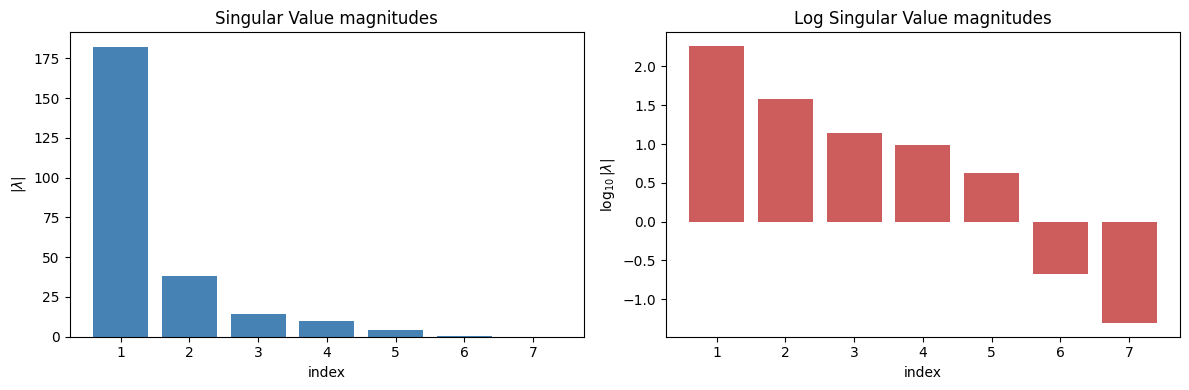

 21%|██        | 311/1500 [01:23<09:13,  2.15it/s]

episode 310 avg_rewarg: 20.3


 21%|██▏       | 321/1500 [01:28<09:20,  2.11it/s]

episode 320 avg_rewarg: 25.9


 22%|██▏       | 331/1500 [01:32<09:46,  1.99it/s]

episode 330 avg_rewarg: 20.1


 23%|██▎       | 341/1500 [01:38<09:53,  1.95it/s]

episode 340 avg_rewarg: 26.6


 23%|██▎       | 350/1500 [01:42<10:04,  1.90it/s]

episode 350 avg_rewarg: 24.3
Hankel Value Function


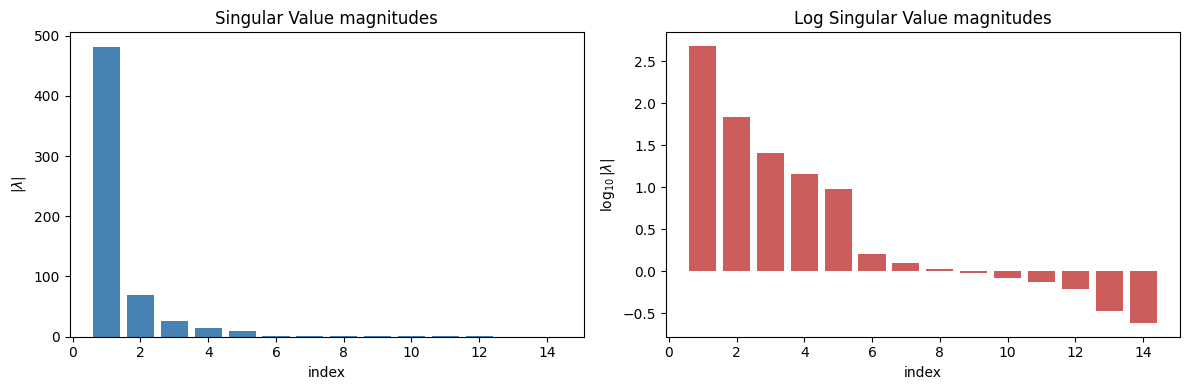

 24%|██▍       | 361/1500 [01:48<10:26,  1.82it/s]

episode 360 avg_rewarg: 22.6


 25%|██▍       | 371/1500 [01:54<10:23,  1.81it/s]

episode 370 avg_rewarg: 20.2


 25%|██▌       | 381/1500 [02:00<10:24,  1.79it/s]

episode 380 avg_rewarg: 19.3


 26%|██▌       | 391/1500 [02:05<11:13,  1.65it/s]

episode 390 avg_rewarg: 19.2


 27%|██▋       | 400/1500 [02:11<10:33,  1.74it/s]

episode 400 avg_rewarg: 16.6
Hankel Value Function


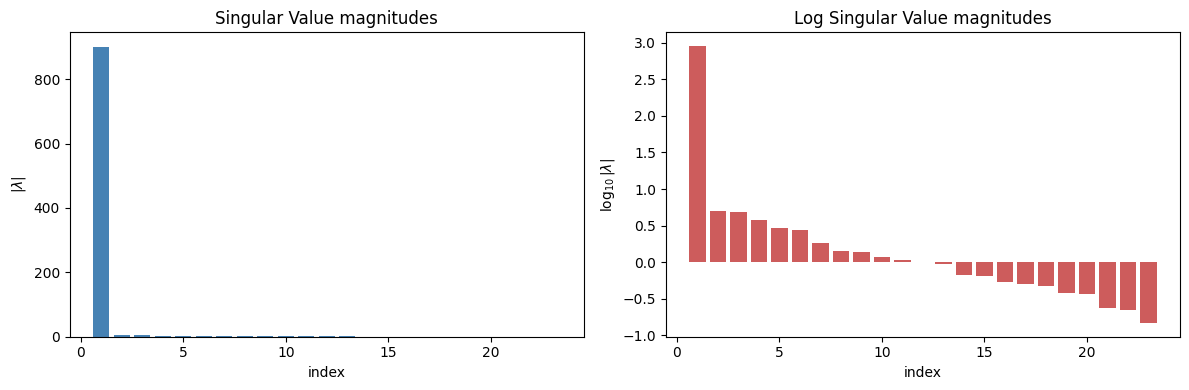

 27%|██▋       | 411/1500 [02:17<10:52,  1.67it/s]

episode 410 avg_rewarg: 18.4


 28%|██▊       | 421/1500 [02:24<11:18,  1.59it/s]

episode 420 avg_rewarg: 30.3


 29%|██▊       | 431/1500 [02:30<11:39,  1.53it/s]

episode 430 avg_rewarg: 18.6


 29%|██▉       | 441/1500 [02:37<12:39,  1.40it/s]

episode 440 avg_rewarg: 27.4


 30%|███       | 450/1500 [02:45<15:21,  1.14it/s]

episode 450 avg_rewarg: 22.1
Hankel Value Function


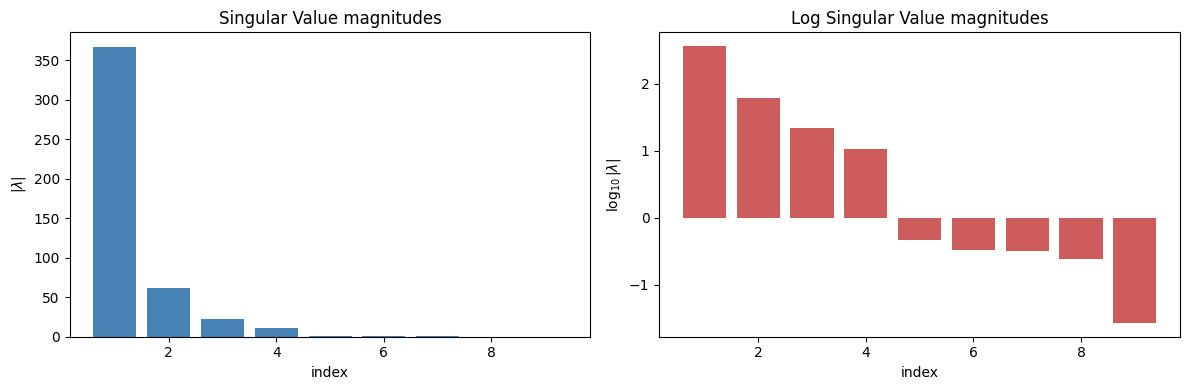

 31%|███       | 461/1500 [02:52<11:48,  1.47it/s]

episode 460 avg_rewarg: 18.3


 31%|███▏      | 471/1500 [02:59<12:06,  1.42it/s]

episode 470 avg_rewarg: 29.3


 32%|███▏      | 481/1500 [03:07<12:52,  1.32it/s]

episode 480 avg_rewarg: 24.1


 33%|███▎      | 491/1500 [03:15<12:33,  1.34it/s]

episode 490 avg_rewarg: 26.8


 33%|███▎      | 500/1500 [03:21<12:19,  1.35it/s]

episode 500 avg_rewarg: 23.1
Hankel Value Function


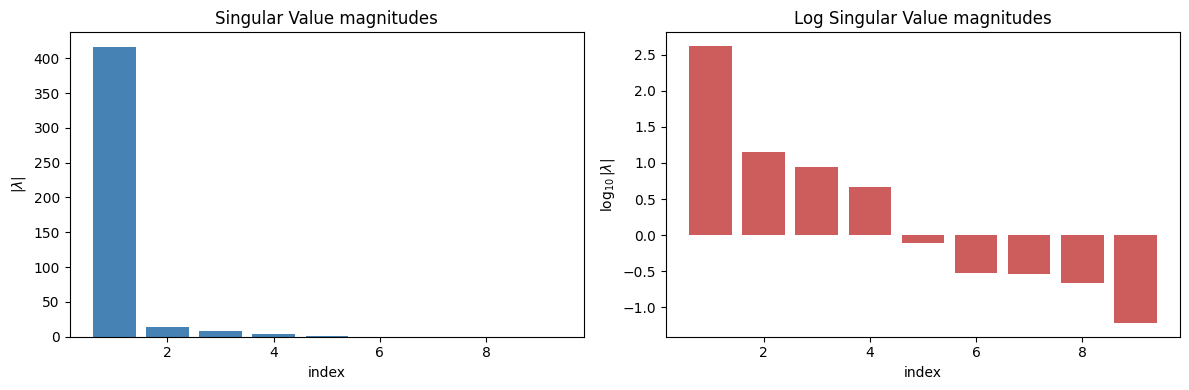

 34%|███▍      | 511/1500 [03:30<12:36,  1.31it/s]

episode 510 avg_rewarg: 23.0


 35%|███▍      | 521/1500 [03:37<12:31,  1.30it/s]

episode 520 avg_rewarg: 24.3


 35%|███▌      | 531/1500 [03:45<12:41,  1.27it/s]

episode 530 avg_rewarg: 22.2


 36%|███▌      | 541/1500 [03:53<12:50,  1.24it/s]

episode 540 avg_rewarg: 24.7


 37%|███▋      | 550/1500 [04:01<12:47,  1.24it/s]

episode 550 avg_rewarg: 20.1
Hankel Value Function


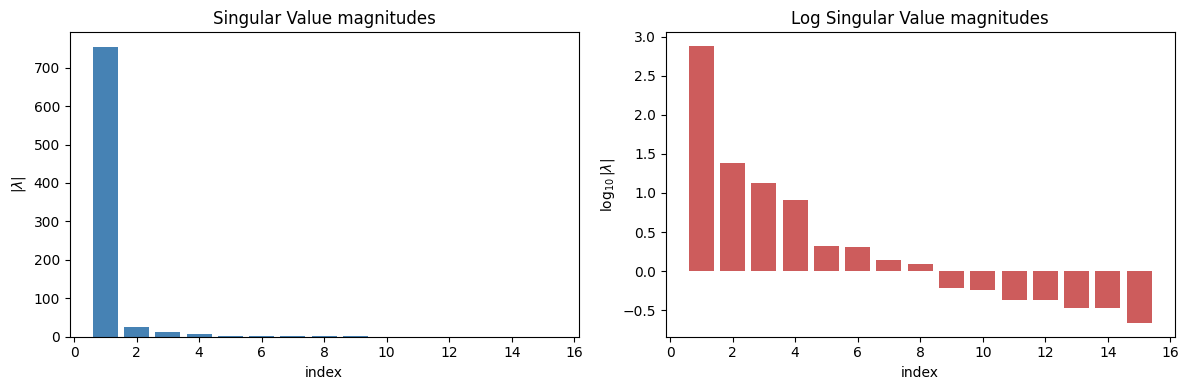

 37%|███▋      | 561/1500 [04:10<13:17,  1.18it/s]

episode 560 avg_rewarg: 21.8


 38%|███▊      | 571/1500 [04:19<13:57,  1.11it/s]

episode 570 avg_rewarg: 41.5


 39%|███▊      | 581/1500 [04:28<14:05,  1.09it/s]

episode 580 avg_rewarg: 41.5


 39%|███▉      | 591/1500 [04:38<13:45,  1.10it/s]

episode 590 avg_rewarg: 27.8


 40%|████      | 600/1500 [04:46<14:24,  1.04it/s]

episode 600 avg_rewarg: 26.1
Hankel Value Function


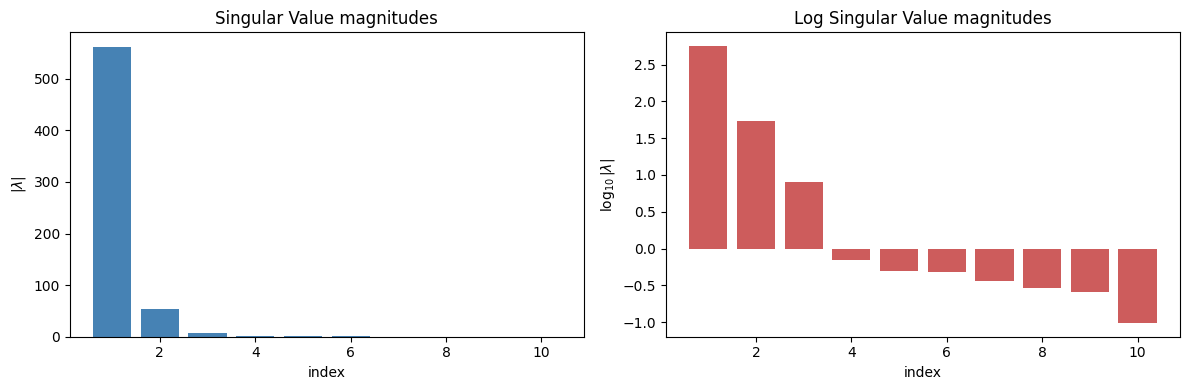

 41%|████      | 611/1500 [05:00<22:11,  1.50s/it]

episode 610 avg_rewarg: 28.8


 41%|████▏     | 621/1500 [05:11<17:09,  1.17s/it]

episode 620 avg_rewarg: 21.6


 42%|████▏     | 631/1500 [05:22<14:18,  1.01it/s]

episode 630 avg_rewarg: 18.3


 43%|████▎     | 641/1500 [05:34<18:07,  1.27s/it]

episode 640 avg_rewarg: 23.2


 43%|████▎     | 650/1500 [05:45<17:03,  1.20s/it]

episode 650 avg_rewarg: 38.7
Hankel Value Function


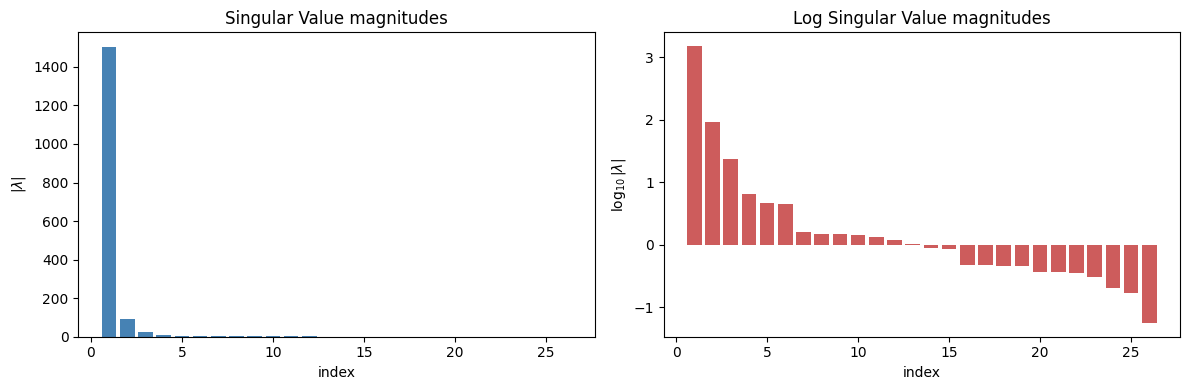

 44%|████▍     | 661/1500 [06:01<29:22,  2.10s/it]

episode 660 avg_rewarg: 35.7


 45%|████▍     | 671/1500 [06:22<18:02,  1.31s/it]  

episode 670 avg_rewarg: 33.0


 45%|████▌     | 681/1500 [06:34<15:15,  1.12s/it]

episode 680 avg_rewarg: 15.1


 46%|████▌     | 691/1500 [06:44<14:42,  1.09s/it]

episode 690 avg_rewarg: 17.7


 47%|████▋     | 700/1500 [06:56<17:08,  1.29s/it]

episode 700 avg_rewarg: 30.0
Hankel Value Function


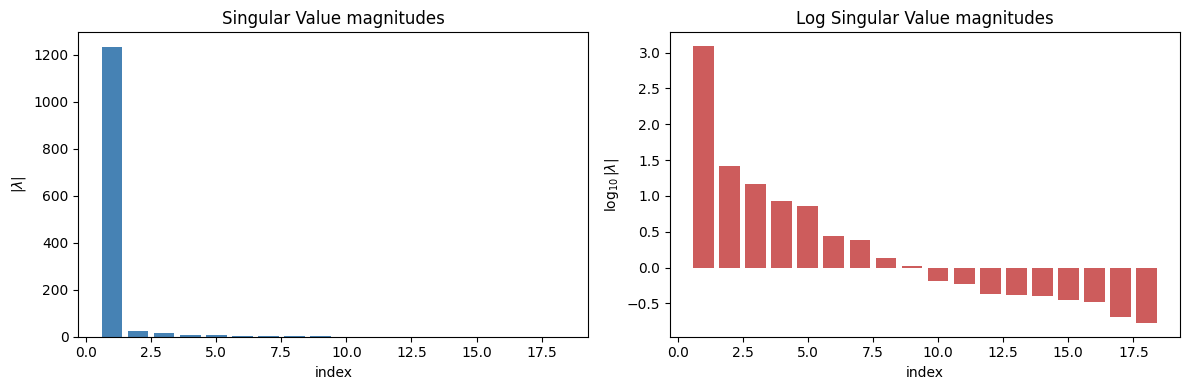

 47%|████▋     | 711/1500 [07:11<16:36,  1.26s/it]

episode 710 avg_rewarg: 16.1


 48%|████▊     | 721/1500 [07:26<18:15,  1.41s/it]

episode 720 avg_rewarg: 19.9


 49%|████▊     | 731/1500 [07:39<18:47,  1.47s/it]

episode 730 avg_rewarg: 29.7


 49%|████▉     | 741/1500 [07:57<18:43,  1.48s/it]

episode 740 avg_rewarg: 26.9


 50%|█████     | 750/1500 [08:07<15:37,  1.25s/it]

episode 750 avg_rewarg: 21.1
Hankel Value Function


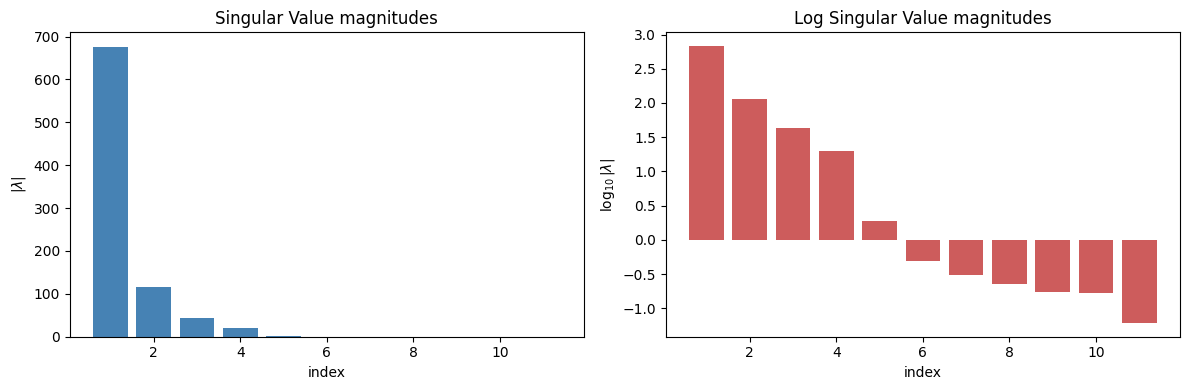

 51%|█████     | 761/1500 [08:22<19:49,  1.61s/it]

episode 760 avg_rewarg: 25.8


 51%|█████▏    | 771/1500 [08:37<19:07,  1.57s/it]

episode 770 avg_rewarg: 23.9


 52%|█████▏    | 781/1500 [08:49<14:10,  1.18s/it]

episode 780 avg_rewarg: 17.1


 53%|█████▎    | 791/1500 [09:04<15:32,  1.32s/it]

episode 790 avg_rewarg: 17.7


 53%|█████▎    | 800/1500 [09:15<14:22,  1.23s/it]

episode 800 avg_rewarg: 33.9
Hankel Value Function


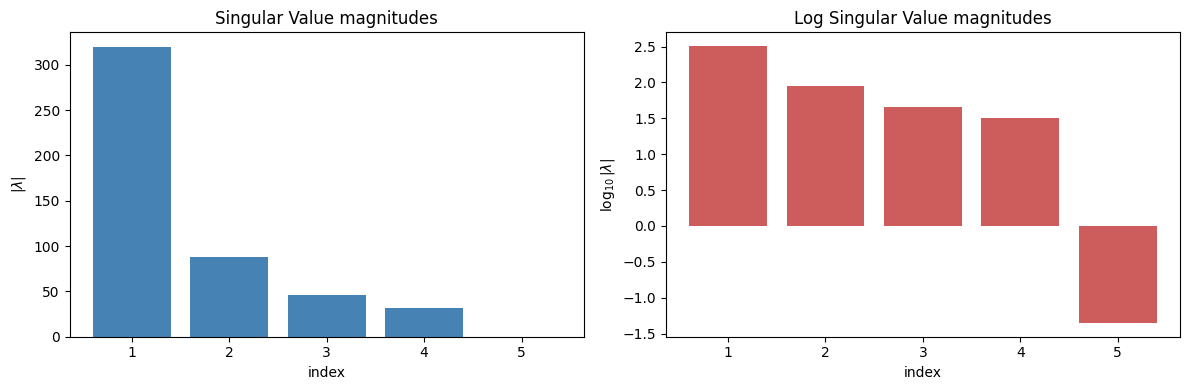

 54%|█████▍    | 811/1500 [09:31<15:10,  1.32s/it]

episode 810 avg_rewarg: 16.5


 55%|█████▍    | 821/1500 [09:47<16:44,  1.48s/it]

episode 820 avg_rewarg: 22.4


 55%|█████▌    | 831/1500 [09:59<13:48,  1.24s/it]

episode 830 avg_rewarg: 22.0


 56%|█████▌    | 841/1500 [10:17<24:59,  2.27s/it]

episode 840 avg_rewarg: 17.5


 57%|█████▋    | 850/1500 [10:29<13:47,  1.27s/it]

episode 850 avg_rewarg: 15.2
Hankel Value Function


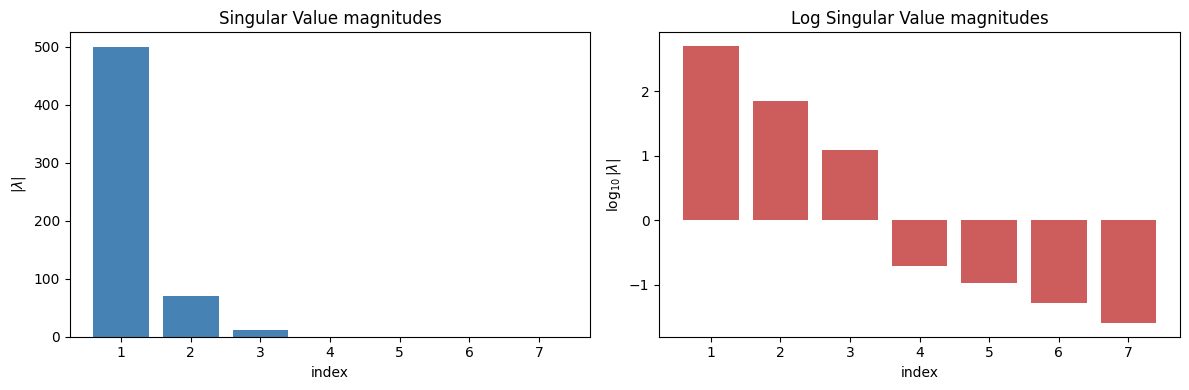

 57%|█████▋    | 861/1500 [10:43<13:33,  1.27s/it]

episode 860 avg_rewarg: 16.1


 58%|█████▊    | 871/1500 [10:58<18:51,  1.80s/it]

episode 870 avg_rewarg: 17.4


 59%|█████▊    | 881/1500 [11:15<15:30,  1.50s/it]

episode 880 avg_rewarg: 20.5


 59%|█████▉    | 891/1500 [11:28<13:03,  1.29s/it]

episode 890 avg_rewarg: 17.6


 60%|██████    | 900/1500 [11:39<13:12,  1.32s/it]

episode 900 avg_rewarg: 21.6
Hankel Value Function


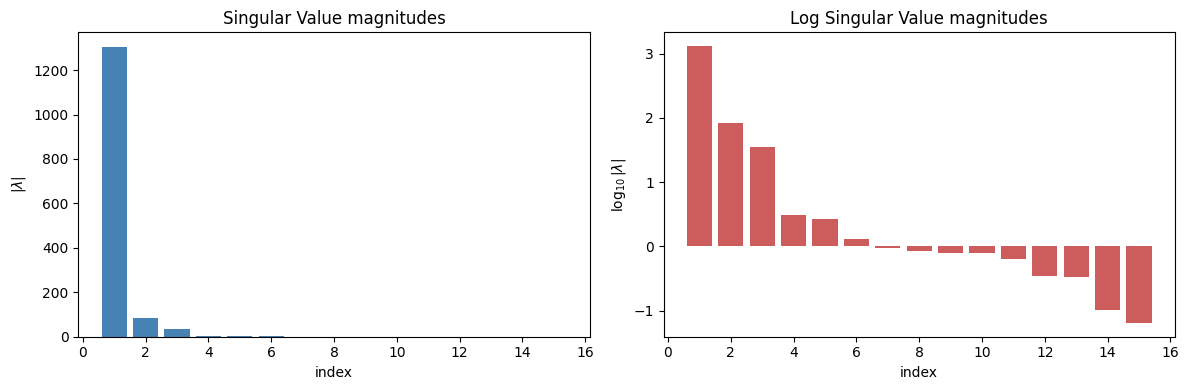

 61%|██████    | 911/1500 [12:01<22:18,  2.27s/it]

episode 910 avg_rewarg: 18.4


 61%|██████▏   | 921/1500 [12:17<13:57,  1.45s/it]

episode 920 avg_rewarg: 22.0


 62%|██████▏   | 931/1500 [12:30<13:08,  1.39s/it]

episode 930 avg_rewarg: 22.5


 63%|██████▎   | 941/1500 [12:47<14:38,  1.57s/it]

episode 940 avg_rewarg: 22.0


 63%|██████▎   | 950/1500 [13:03<18:03,  1.97s/it]

episode 950 avg_rewarg: 21.4
Hankel Value Function


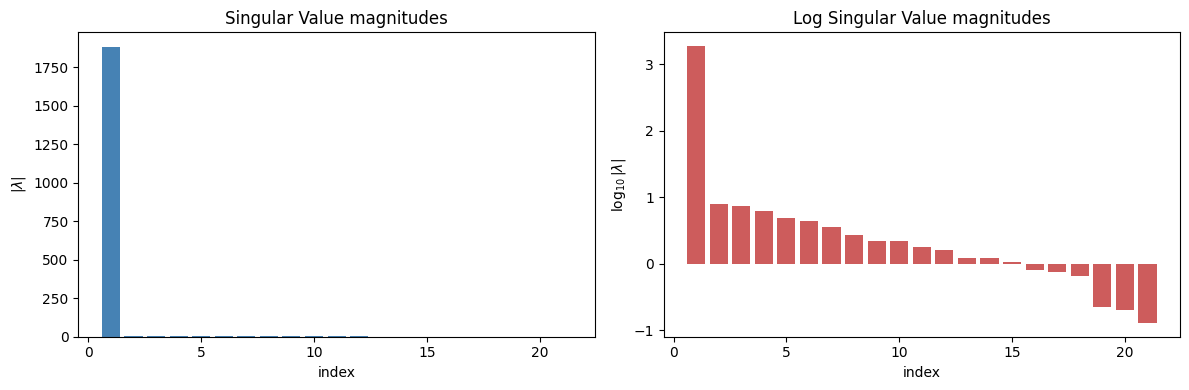

 64%|██████▍   | 961/1500 [13:18<12:23,  1.38s/it]

episode 960 avg_rewarg: 11.1


 65%|██████▍   | 971/1500 [13:37<18:55,  2.15s/it]

episode 970 avg_rewarg: 23.4


 65%|██████▌   | 981/1500 [13:51<12:07,  1.40s/it]

episode 980 avg_rewarg: 17.0


 66%|██████▌   | 991/1500 [14:06<12:27,  1.47s/it]

episode 990 avg_rewarg: 27.5


 67%|██████▋   | 1000/1500 [14:22<15:21,  1.84s/it]

episode 1000 avg_rewarg: 33.6
Hankel Value Function


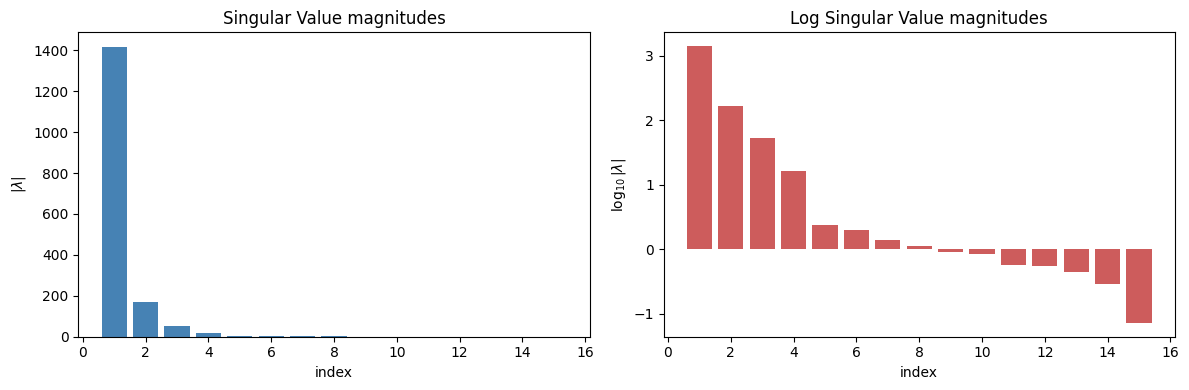

 67%|██████▋   | 1011/1500 [14:42<12:44,  1.56s/it]

episode 1010 avg_rewarg: 21.9


 68%|██████▊   | 1021/1500 [14:57<12:38,  1.58s/it]

episode 1020 avg_rewarg: 22.1


 69%|██████▊   | 1031/1500 [15:17<12:55,  1.65s/it]

episode 1030 avg_rewarg: 21.1


 69%|██████▉   | 1041/1500 [15:31<11:30,  1.50s/it]

episode 1040 avg_rewarg: 21.2


 70%|███████   | 1050/1500 [15:48<15:58,  2.13s/it]

episode 1050 avg_rewarg: 21.0
Hankel Value Function


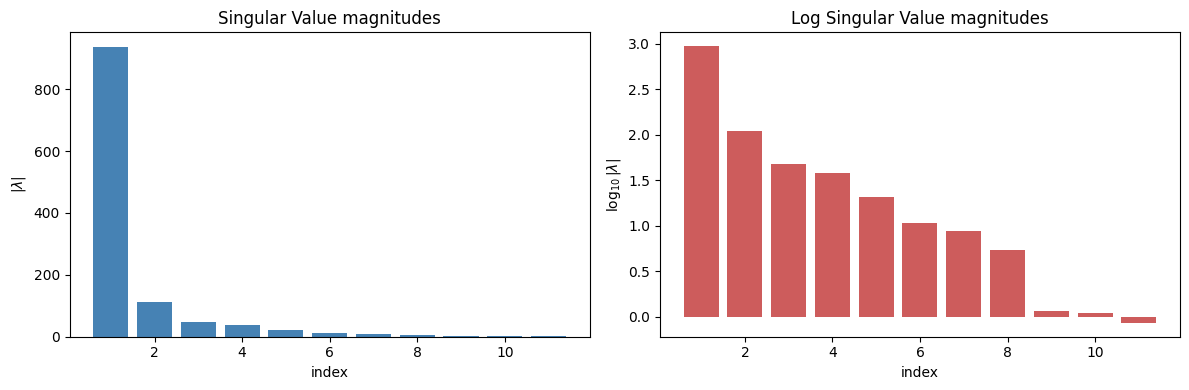

 71%|███████   | 1061/1500 [16:07<11:45,  1.61s/it]

episode 1060 avg_rewarg: 14.5


 71%|███████▏  | 1071/1500 [16:23<11:18,  1.58s/it]

episode 1070 avg_rewarg: 20.8


 72%|███████▏  | 1081/1500 [16:42<14:27,  2.07s/it]

episode 1080 avg_rewarg: 24.4


 73%|███████▎  | 1091/1500 [16:57<10:40,  1.57s/it]

episode 1090 avg_rewarg: 21.9


 73%|███████▎  | 1100/1500 [17:11<10:26,  1.57s/it]

episode 1100 avg_rewarg: 21.4
Hankel Value Function


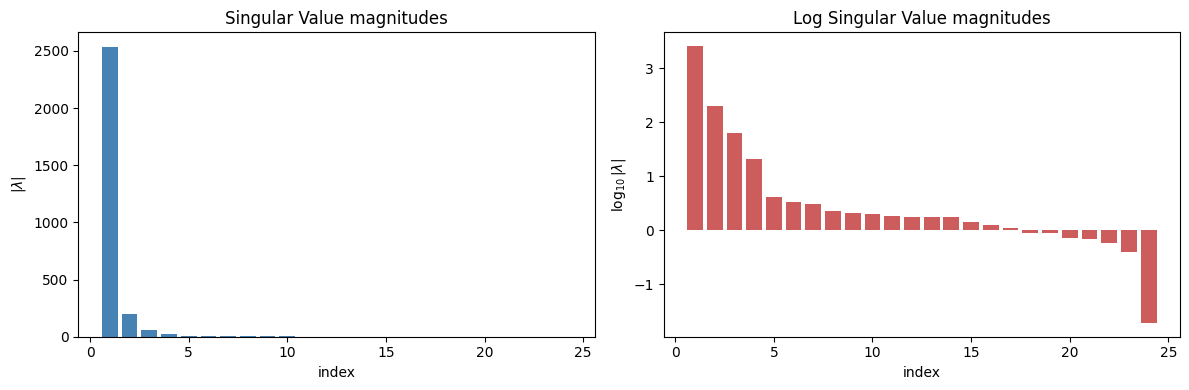

 74%|███████▍  | 1111/1500 [17:32<13:23,  2.07s/it]

episode 1110 avg_rewarg: 22.7


 75%|███████▍  | 1121/1500 [17:49<10:27,  1.66s/it]

episode 1120 avg_rewarg: 18.4


 75%|███████▌  | 1131/1500 [18:05<09:56,  1.62s/it]

episode 1130 avg_rewarg: 18.5


 76%|███████▌  | 1141/1500 [20:55<1:44:25, 17.45s/it]

episode 1140 avg_rewarg: 22.3


 77%|███████▋  | 1150/1500 [21:12<14:33,  2.50s/it]  

episode 1150 avg_rewarg: 33.1
Hankel Value Function


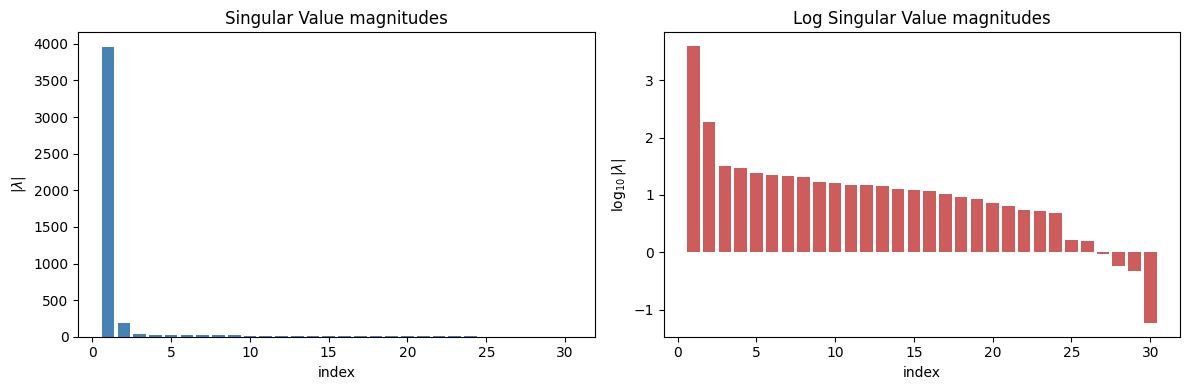

 77%|███████▋  | 1161/1500 [21:32<09:58,  1.76s/it]

episode 1160 avg_rewarg: 17.1


 78%|███████▊  | 1171/1500 [21:56<12:29,  2.28s/it]

episode 1170 avg_rewarg: 14.4


 79%|███████▊  | 1181/1500 [22:14<09:13,  1.73s/it]

episode 1180 avg_rewarg: 28.5


 79%|███████▉  | 1191/1500 [22:32<09:04,  1.76s/it]

episode 1190 avg_rewarg: 20.8


 80%|████████  | 1200/1500 [22:51<11:12,  2.24s/it]

episode 1200 avg_rewarg: 24.6
Hankel Value Function


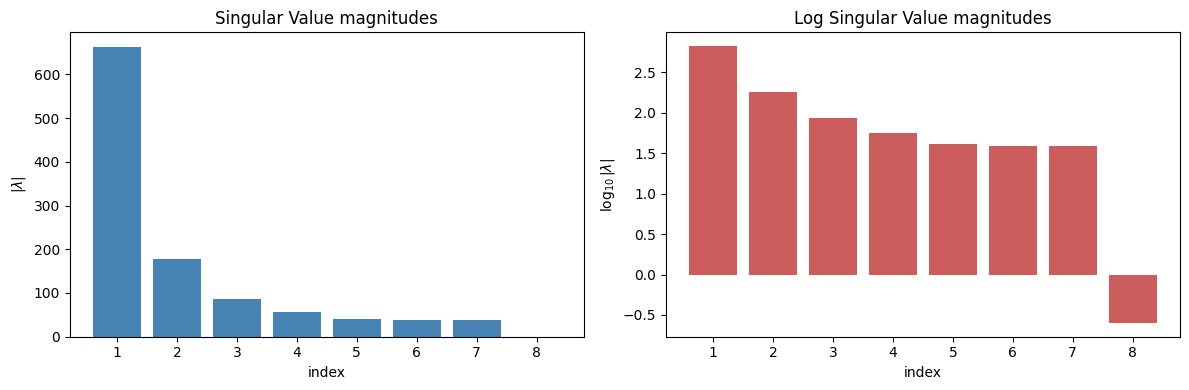

 81%|████████  | 1211/1500 [23:11<08:35,  1.78s/it]

episode 1210 avg_rewarg: 21.7


 81%|████████▏ | 1221/1500 [23:32<11:27,  2.46s/it]

episode 1220 avg_rewarg: 14.1


 82%|████████▏ | 1231/1500 [23:49<08:13,  1.84s/it]

episode 1230 avg_rewarg: 22.8


 83%|████████▎ | 1241/1500 [24:07<07:37,  1.77s/it]

episode 1240 avg_rewarg: 19.1


 83%|████████▎ | 1250/1500 [24:27<08:50,  2.12s/it]

episode 1250 avg_rewarg: 23.9
Hankel Value Function


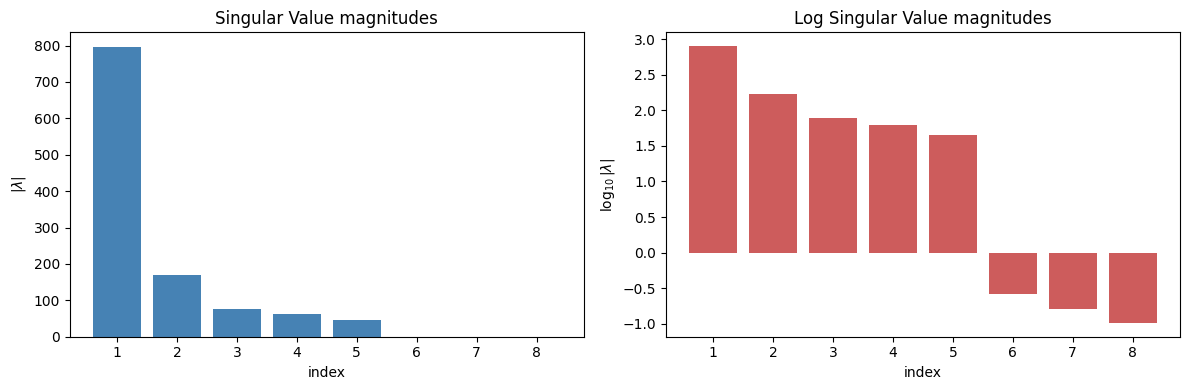

 84%|████████▍ | 1261/1500 [24:48<07:52,  1.98s/it]

episode 1260 avg_rewarg: 25.1


 85%|████████▍ | 1271/1500 [25:06<07:06,  1.86s/it]

episode 1270 avg_rewarg: 20.9


 85%|████████▌ | 1281/1500 [25:28<06:57,  1.91s/it]

episode 1280 avg_rewarg: 20.4


 86%|████████▌ | 1291/1500 [25:46<06:22,  1.83s/it]

episode 1290 avg_rewarg: 14.8


 87%|████████▋ | 1300/1500 [26:06<07:38,  2.29s/it]

episode 1300 avg_rewarg: 48.0
Hankel Value Function


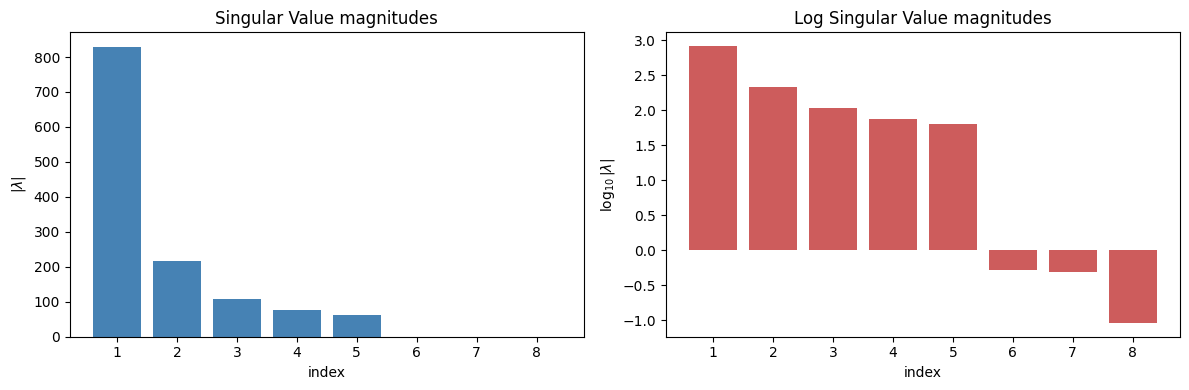

 87%|████████▋ | 1311/1500 [26:28<06:00,  1.91s/it]

episode 1310 avg_rewarg: 17.8


 88%|████████▊ | 1321/1500 [26:49<07:29,  2.51s/it]

episode 1320 avg_rewarg: 14.1


 89%|████████▊ | 1331/1500 [27:10<05:28,  1.95s/it]

episode 1330 avg_rewarg: 16.2


 89%|████████▉ | 1341/1500 [27:29<05:11,  1.96s/it]

episode 1340 avg_rewarg: 26.1


 90%|█████████ | 1350/1500 [27:50<05:33,  2.22s/it]

episode 1350 avg_rewarg: 25.9
Hankel Value Function


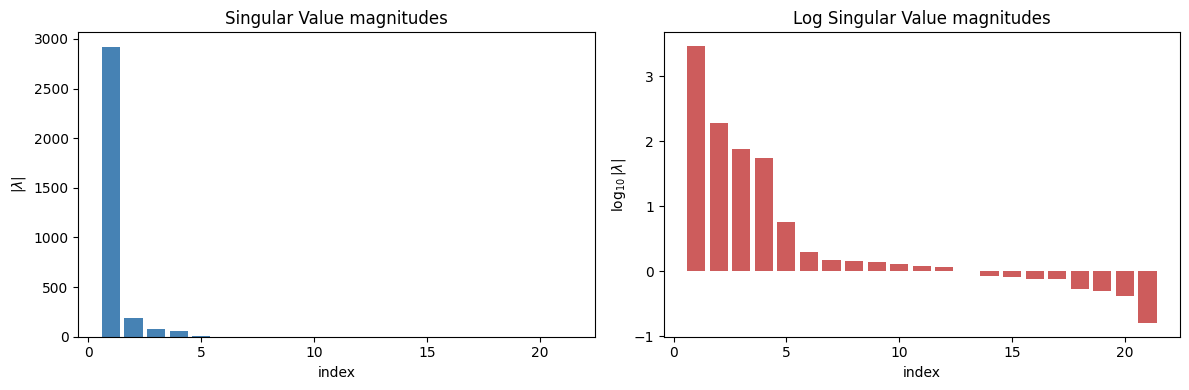

 91%|█████████ | 1361/1500 [28:12<04:38,  2.00s/it]

episode 1360 avg_rewarg: 21.1


 91%|█████████▏| 1371/1500 [28:35<04:32,  2.11s/it]

episode 1370 avg_rewarg: 19.8


 92%|█████████▏| 1381/1500 [28:55<03:58,  2.00s/it]

episode 1380 avg_rewarg: 25.3


 93%|█████████▎| 1391/1500 [29:17<04:13,  2.33s/it]

episode 1390 avg_rewarg: 29.0


 93%|█████████▎| 1400/1500 [29:37<03:25,  2.06s/it]

episode 1400 avg_rewarg: 31.9
Hankel Value Function


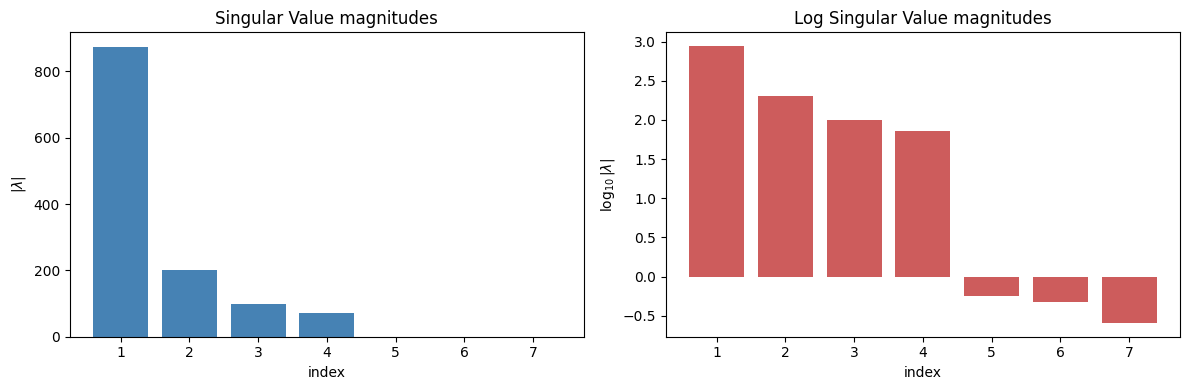

 94%|█████████▍| 1411/1500 [30:00<03:08,  2.12s/it]

episode 1410 avg_rewarg: 26.2


 95%|█████████▍| 1421/1500 [30:24<02:49,  2.15s/it]

episode 1420 avg_rewarg: 19.6


 95%|█████████▌| 1431/1500 [30:44<02:24,  2.09s/it]

episode 1430 avg_rewarg: 17.7


 96%|█████████▌| 1441/1500 [31:08<02:04,  2.12s/it]

episode 1440 avg_rewarg: 26.3


 97%|█████████▋| 1450/1500 [31:27<01:47,  2.15s/it]

episode 1450 avg_rewarg: 28.9
Hankel Value Function


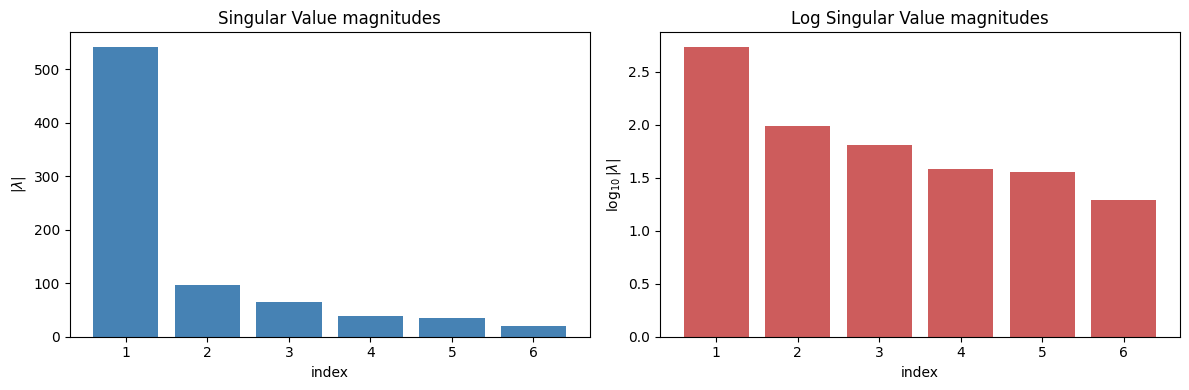

 97%|█████████▋| 1461/1500 [31:54<01:43,  2.64s/it]

episode 1460 avg_rewarg: 16.7


 98%|█████████▊| 1471/1500 [32:17<01:03,  2.18s/it]

episode 1470 avg_rewarg: 27.2


 99%|█████████▊| 1481/1500 [32:43<00:48,  2.57s/it]

episode 1480 avg_rewarg: 25.1


 99%|█████████▉| 1491/1500 [33:05<00:20,  2.23s/it]

episode 1490 avg_rewarg: 32.1


100%|██████████| 1500/1500 [33:27<00:00,  1.34s/it]


In [19]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    np_seed=seed,
    analysis_config = analysis
)

## Training and Analysis Plots (now with pi*(theeta))

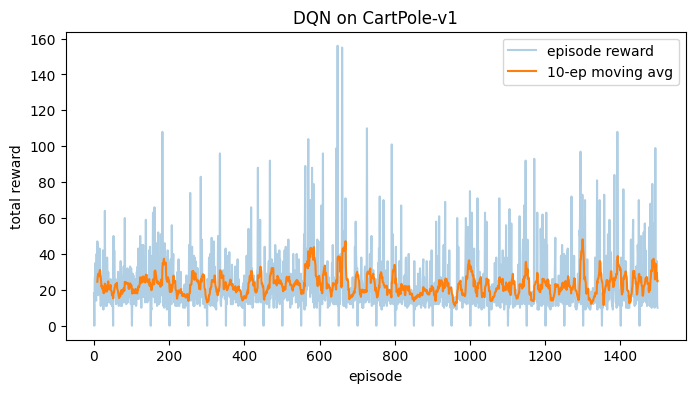

In [20]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on CartPole-v1")
plt.legend(); plt.show()

Hankel Value Function


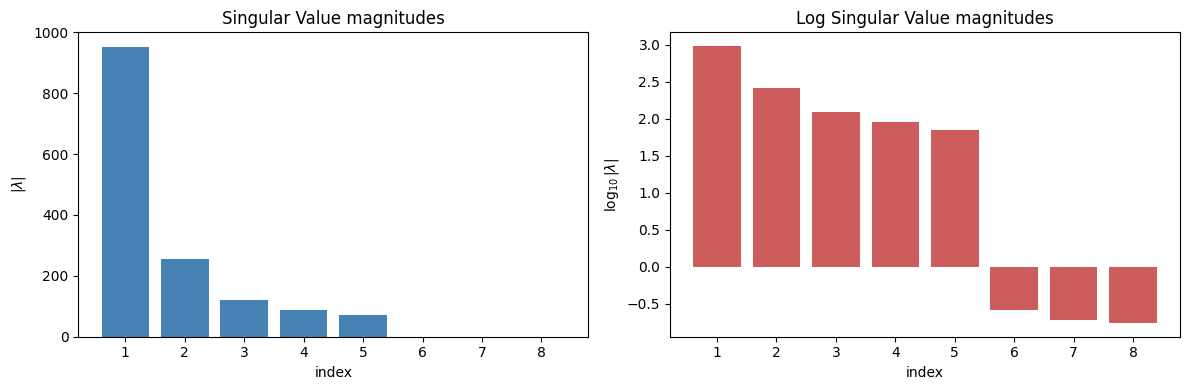

In [21]:
for method,name in zip(analysis["methods"], ['Hankel Value Function','Q-function']):
    print(name)
    matrix = method(agent=agent, env=env)
    plot_matrix_spectra(matrix)